# Polynomial Regression
- degree 1 = straight line graph - underfitting
- degree 2 = parabola shape graph, good fit
- degree 3 = S shape graph -  overfitting

In [2]:
import numpy as np
import matplotlib.pyplot as plt

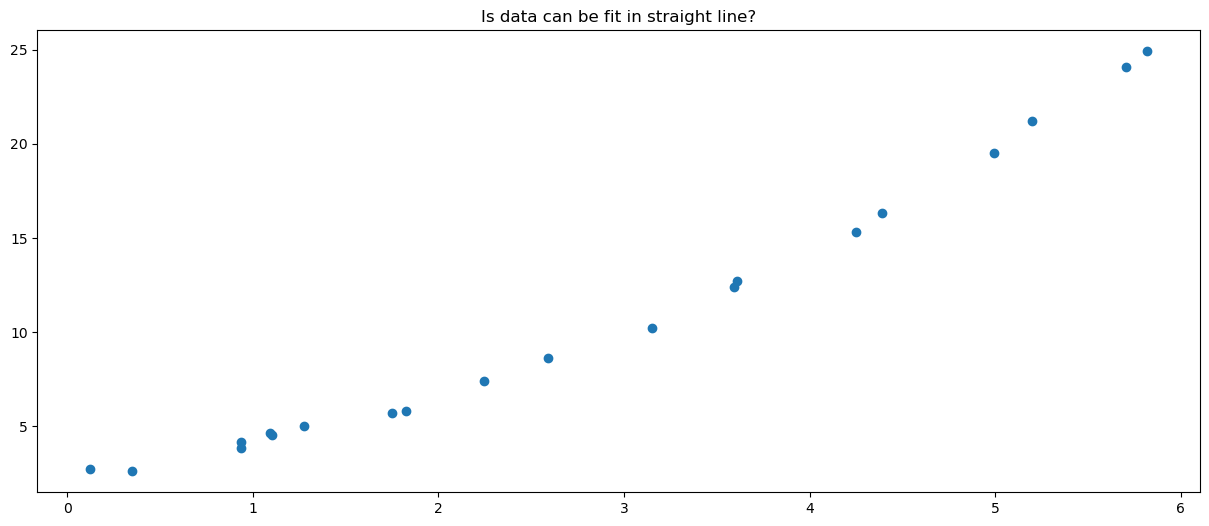

In [3]:
np.random.seed(42)

X = np.sort(np.random.rand(20, 1)*6)
y = 0.5*X**2 + X + 2 + np.random.rand(20, 1)

plt.figure(figsize=(15, 6))
plt.scatter(X, y)
plt.title("Is data can be fit in straight line?")
plt.show()

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

lr = LinearRegression()
lr.fit(X_poly, y)
print("Original data")
print(X)
print()
print("Transformed data with degree 3")
print(X_poly)

Original data
[[2.24724071]
 [5.70428584]
 [4.39196365]
 [3.59195091]
 [0.93611184]
 [0.93596712]
 [0.34850167]
 [5.19705687]
 [3.60669007]
 [4.24843547]
 [0.12350697]
 [5.81945911]
 [4.99465584]
 [1.27403466]
 [1.0909498 ]
 [1.10042706]
 [1.82545346]
 [3.14853859]
 [2.59167011]
 [1.74737484]]

Transformed data with degree 3
[[1.00000000e+00 2.24724071e+00 5.05009082e+00 1.13487697e+01]
 [1.00000000e+00 5.70428584e+00 3.25388769e+01 1.85611055e+02]
 [1.00000000e+00 4.39196365e+00 1.92893447e+01 8.47181008e+01]
 [1.00000000e+00 3.59195091e+00 1.29021113e+01 4.63437504e+01]
 [1.00000000e+00 9.36111843e-01 8.76305382e-01 8.20319846e-01]
 [1.00000000e+00 9.35967122e-01 8.76034453e-01 8.19939446e-01]
 [1.00000000e+00 3.48501673e-01 1.21453416e-01 4.23267187e-02]
 [1.00000000e+00 5.19705687e+00 2.70094002e+01 1.40369389e+02]
 [1.00000000e+00 3.60669007e+00 1.30082133e+01 4.69165936e+01]
 [1.00000000e+00 4.24843547e+00 1.80492039e+01 7.66808781e+01]
 [1.00000000e+00 1.23506966e-01 1.52539706e

In [5]:
print(X.shape, X_poly.shape)

(20, 1) (20, 4)


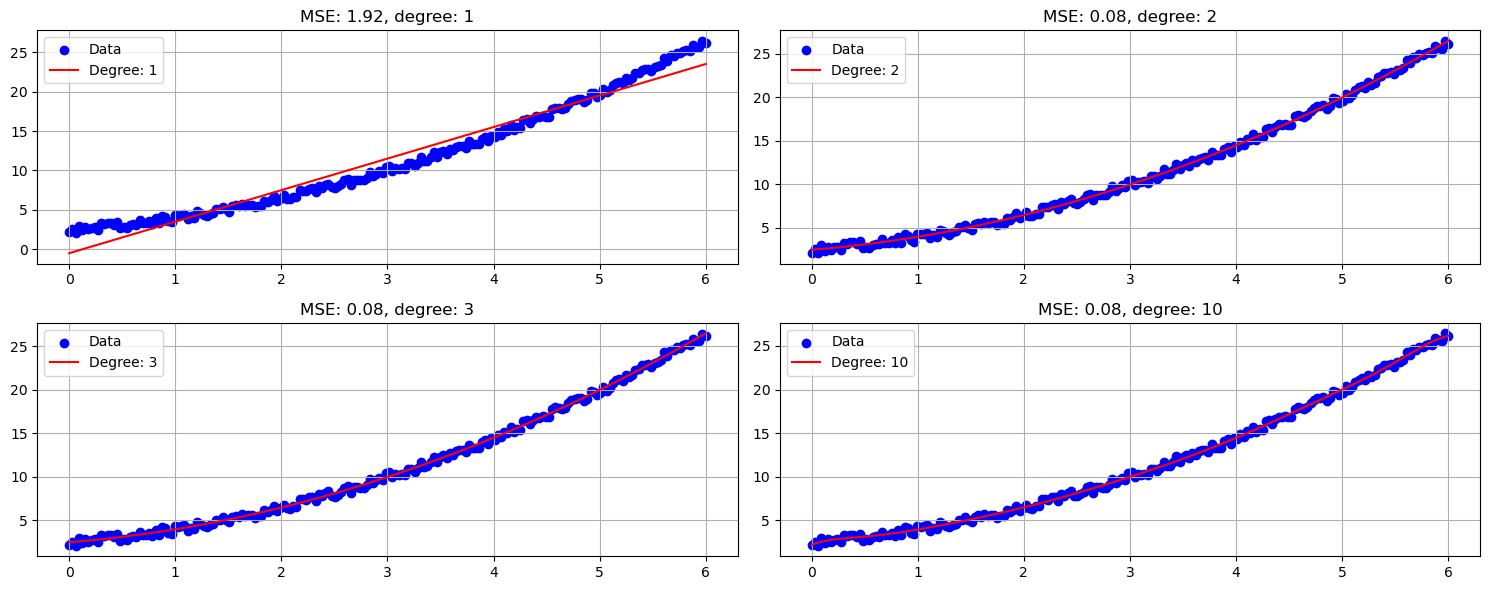

In [ ]:
# comparing degrees in plots
# lets compare 1, 2, 3, 10


fig, axes = plt.subplots(2, 2, figsize=(15, 6))
X = np.linspace(0, 6, 200).reshape(-1, 1)
y = 0.5*X**2 + X + 2 + np.random.rand(200, 1)

for ax, degree in zip(axes.ravel(), [1, 2, 3, 10]):
  #polynomial features
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X)
  #fitting
  lr = LinearRegression()
  lr.fit(X_poly, y)
  y_pred = lr.predict(X_poly)

  # mse calc
  mse = np.mean((y_pred-y)**2)

  # lets plot
  ax.scatter(X, y, color="blue", label="Data")
  ax.plot(X, y_pred, "r-", label=f'Degree: {degree}')
  ax.set_title(f'MSE: {mse:.2f}, degree: {degree}')
  ax.legend()
  ax.grid(True)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# lets see coefficients of degree 10
poly10 = PolynomialFeatures(degree=10)
X_poly10 = poly10.fit_transform(X)
X_poly10_s = scaler.fit_transform(X_poly10)
lr10 = LinearRegression()
lr10.fit(X_poly10_s, y)
print(lr10.coef_.round(2))

[[ 0.000000e+00  8.840000e+00 -1.562900e+02  1.560710e+03 -8.330030e+03
   2.714882e+04 -5.619047e+04  7.408818e+04 -6.021363e+04  2.746799e+04
  -5.376990e+03]]
